# EDA: Detecção de Fraude (IEEE-CIS)

Semana 1: investigar estrutura dos dados, padrões de valores ausentes por classe, e definir o split temporal.

In [19]:
import sys
from pathlib import Path


def _find_project_root(marker: str = "src") -> Path:
    """Sobe diretórios a partir do cwd até achar a raiz do projeto.

    Mais robusto que `sys.path.append('..')`: não depende de o notebook
    ser executado a partir de `notebooks/` especificamente.
    """
    path = Path.cwd().resolve()
    for parent in [path, *path.parents]:
        if (parent / marker).is_dir():
            return parent
    raise RuntimeError(f"Não encontrei um diretório '{marker}' subindo a partir de {path}")


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import FIGURES_DIR
from src.data_loader import load_raw_data
from src.preprocessing import report_missing_by_class, temporal_train_test_split

df = load_raw_data()
df.shape

(590540, 434)

In [20]:
df_ordenado = df.sort_values(by="TransactionDT")
df_ordenado.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


## Taxa de fraude e desbalanceamento

In [21]:
df['isFraud'].value_counts(normalize=True)

isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

## Valores ausentes: fraude vs. não-fraude

A ausência de um dado pode ser, ela mesma, um sinal: checar antes de imputar.

In [22]:
report_missing_by_class(df).head(20)

,missing_rate_fraud,missing_rate_legit,diff
R_emaildomain,0.456662,0.778787,0.322126
id_02,0.456904,0.772495,0.315591
id_36,0.456904,0.772296,0.315393
id_37,0.456904,0.772296,0.315393
id_35,0.456904,0.772296,0.315393
id_38,0.456904,0.772296,0.315393
id_15,0.456904,0.772296,0.315393
id_11,0.457097,0.772302,0.315205
id_29,0.457097,0.772302,0.315205
id_28,0.457097,0.772302,0.315205


### É sinal de risco, ou é composição de produto?

A comparação bruta acima mistura todos os `ProductCD`. Antes de interpretar a ausência como sinal de risco, vale checar se não é apenas um efeito de produtos diferentes terem cobertura de `identity` (e taxas de fraude) diferentes.

In [23]:
print("Cobertura de id_02 (dado de identidade presente) por ProductCD:")
print(df.groupby("ProductCD", observed=True)["id_02"].apply(lambda s: s.notna().mean()).sort_values(ascending=False))

print()
print("Taxa de ausência de id_02 por ProductCD x isFraud:")
missing_by_product_class = (
    df.groupby(["ProductCD", "isFraud"], observed=True)["id_02"]
    .apply(lambda s: s.isna().mean())
    .unstack("isFraud")
)
missing_by_product_class.columns = ["missing_legit", "missing_fraud"]
missing_by_product_class["diff_pp"] = (
    missing_by_product_class["missing_legit"] - missing_by_product_class["missing_fraud"]
) * 100
print(missing_by_product_class)

Cobertura de id_02 (dado de identidade presente) por ProductCD:
ProductCD
H    0.971990
S    0.969986
R    0.967638
C    0.890483
W    0.000000
Name: id_02, dtype: float64

Taxa de ausência de id_02 por ProductCD x isFraud:
           missing_legit  missing_fraud   diff_pp
ProductCD                                        
C               0.117169       0.051698  6.547048
H               0.029062       0.006989  2.207344
R               0.033220       0.010519  2.270137
S               0.028971       0.046647 -1.767629
W               1.000000       1.000000  0.000000


**O confundidor é real.** `ProductCD == W` responde por ~74% das transações e tem cobertura de `identity` igual a 0%, sempre, fraude ou não. `W` também é o produto com menor taxa de fraude (~2.0%), enquanto `C` (maior taxa de fraude, ~11.7%) tem ~89% de cobertura. Isso sozinho já explica boa parte do gap de ~31 p.p. visto no agregado: basta a fraude estar mais concentrada nos produtos que sempre carregam `identity`.

Condicionando por `ProductCD`, o efeito sobrevive mas encolhe muito (de ~31 p.p. para poucos p.p.) e **não é consistente na direção**: +6.6 p.p. em C, +2.2 p.p. em H, +2.3 p.p. em R (fraude com menos ausência), mas **-1.8 p.p. em S** (o contrário). Conclusão revisada: há um resíduo de sinal real em alguns produtos, mas é pequeno e não generaliza; longe do "sinal de risco forte" que a comparação bruta sugeria. Qualquer *flag* de ausência como feature (Semana 2) deveria ser construída interagindo com `ProductCD`, não isoladamente.

## Análise univariada

Antes de comparar com o target, vale olhar a distribuição de cada variável isoladamente. Escopo limitado às variáveis prioritárias já identificadas (não dá pra plotar as 434 colunas): `TransactionAmt` e as categóricas de negócio (`ProductCD`, `card4`, `card6`, `DeviceType`).

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Paleta do design system do projeto: ordem categórica fixa,
# azul = não-fraude, laranja = fraude; nunca invertida entre gráficos.
COLOR_LEGIT = "#2a78d6"
COLOR_FRAUD = "#eb6834"
COLOR_MUTED = "#898781"
COLOR_GRID = "#e1e0d9"
COLOR_INK = "#0b0b0b"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": COLOR_GRID,
    "axes.labelcolor": COLOR_INK,
    "text.color": COLOR_INK,
    "xtick.color": COLOR_MUTED,
    "ytick.color": COLOR_MUTED,
    "grid.color": COLOR_GRID,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})


def style_ax(ax, title=None):
    ax.grid(axis="y", zorder=0)
    ax.set_axisbelow(True)
    if title:
        ax.set_title(title, loc="left", fontsize=11, color=COLOR_INK)
    return ax

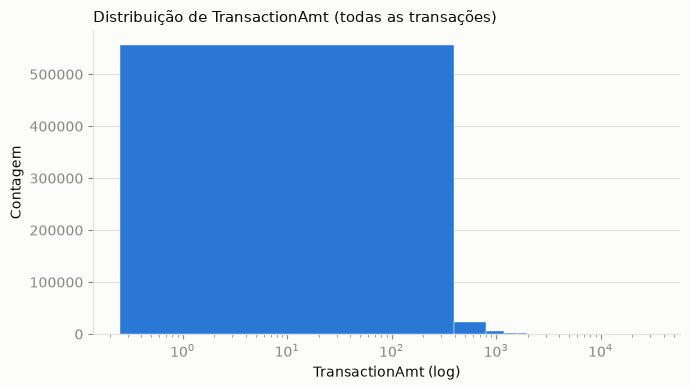

In [25]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["TransactionAmt"], bins=80, color=COLOR_LEGIT, edgecolor="white", linewidth=0.3, zorder=3)
ax.set_xscale("log")
ax.set_xlabel("TransactionAmt (log)")
ax.set_ylabel("Contagem")
style_ax(ax, "Distribuição de TransactionAmt (todas as transações)")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "transaction_amt_dist.png", dpi=150, bbox_inches="tight")
plt.show()

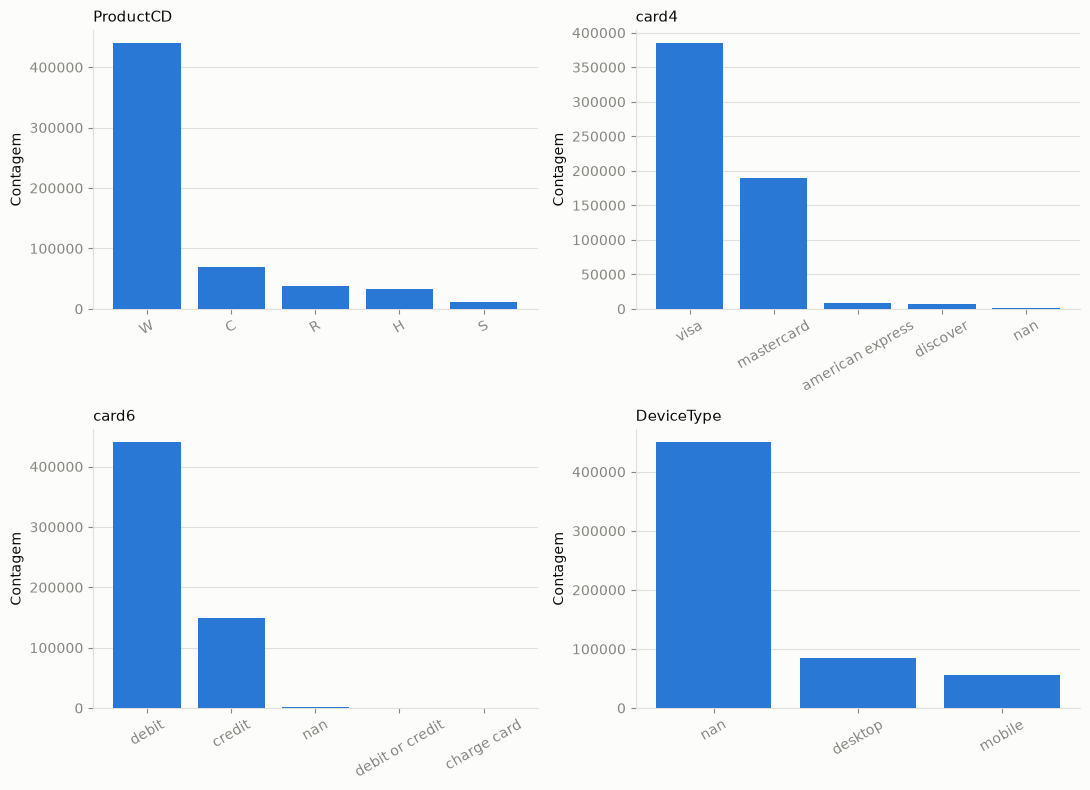

In [26]:
cat_cols = ["ProductCD", "card4", "card6", "DeviceType"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flat, cat_cols):
    counts = df[col].value_counts(dropna=False)
    ax.bar(counts.index.astype(str), counts.values, color=COLOR_LEGIT, zorder=3)
    style_ax(ax, col)
    ax.set_ylabel("Contagem")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "categorical_frequencies.png", dpi=150, bbox_inches="tight")
plt.show()

## Análise bivariada (variável vs. `isFraud`)

Mesmas variáveis, agora separadas por classe. Convenção de cor fixa daqui pra frente: **azul = não-fraude, laranja = fraude** (nunca invertida entre gráficos).

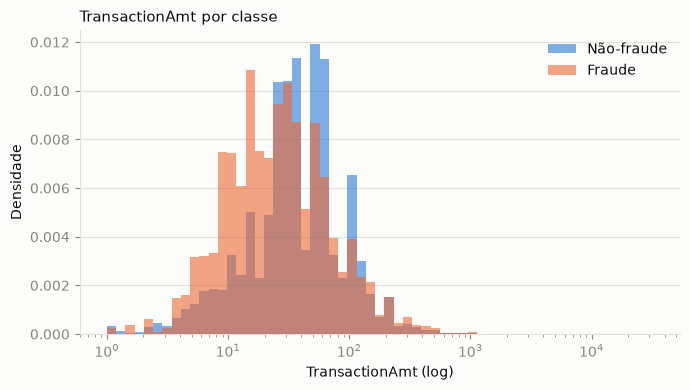

In [27]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.logspace(
    np.log10(df["TransactionAmt"].clip(lower=1).min()),
    np.log10(df["TransactionAmt"].max()),
    60,
)

ax.hist(df.loc[df["isFraud"] == 0, "TransactionAmt"], bins=bins, density=True,
        alpha=0.6, color=COLOR_LEGIT, label="Não-fraude", zorder=3)
ax.hist(df.loc[df["isFraud"] == 1, "TransactionAmt"], bins=bins, density=True,
        alpha=0.6, color=COLOR_FRAUD, label="Fraude", zorder=3)
ax.set_xscale("log")
ax.set_xlabel("TransactionAmt (log)")
ax.set_ylabel("Densidade")
style_ax(ax, "TransactionAmt por classe")
ax.legend(frameon=False)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "transaction_amt_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

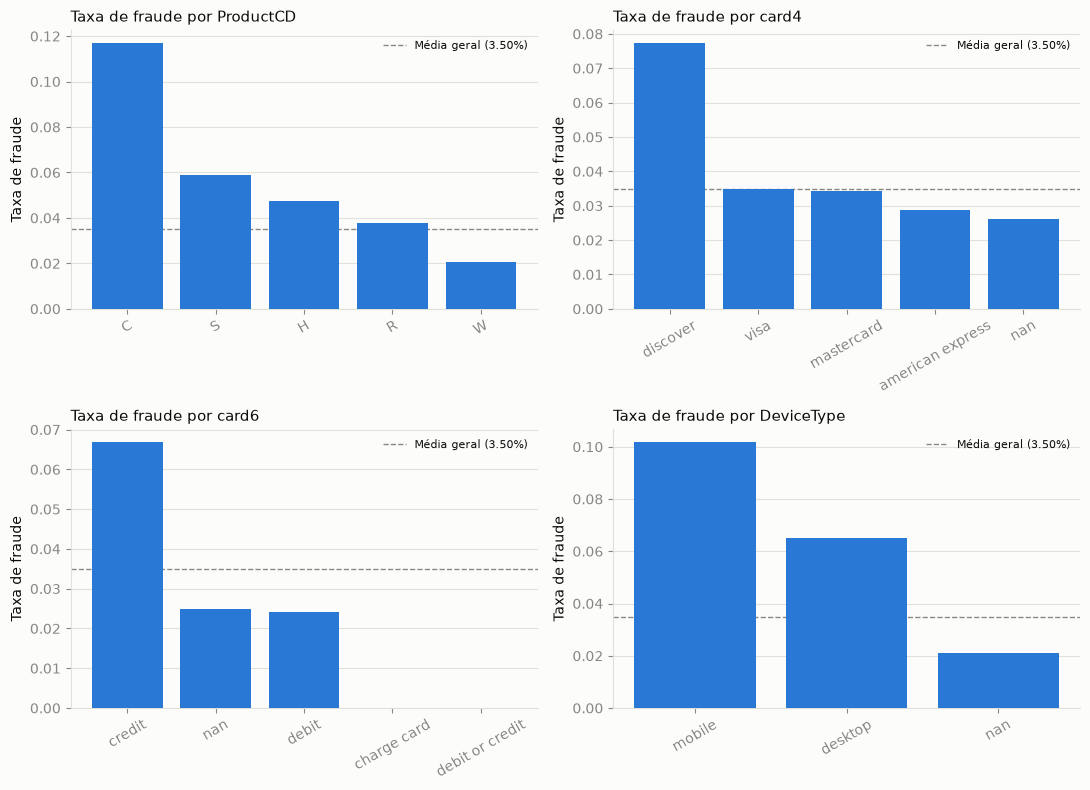

In [28]:
def fraud_rate_by(df, col):
    """Taxa de fraude e contagem por categoria, ordenado da mais pra menos fraudulenta."""
    grouped = df.groupby(col, observed=True, dropna=False)["isFraud"].agg(["mean", "count"])
    return grouped.sort_values("mean", ascending=False)


overall_rate = df["isFraud"].mean()

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flat, cat_cols):
    rates = fraud_rate_by(df, col)
    ax.bar(rates.index.astype(str), rates["mean"], color=COLOR_LEGIT, zorder=3)
    ax.axhline(overall_rate, color=COLOR_MUTED, linestyle="--", linewidth=1, zorder=2,
               label=f"Média geral ({overall_rate:.2%})")
    style_ax(ax, f"Taxa de fraude por {col}")
    ax.set_ylabel("Taxa de fraude")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fraud_rate_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

## Estabilidade da taxa de fraude ao longo do tempo

A taxa agregada (3.50%) pode esconder variação forte dentro do período, é o que este bloco checa antes de afirmar que o split temporal é seguro.

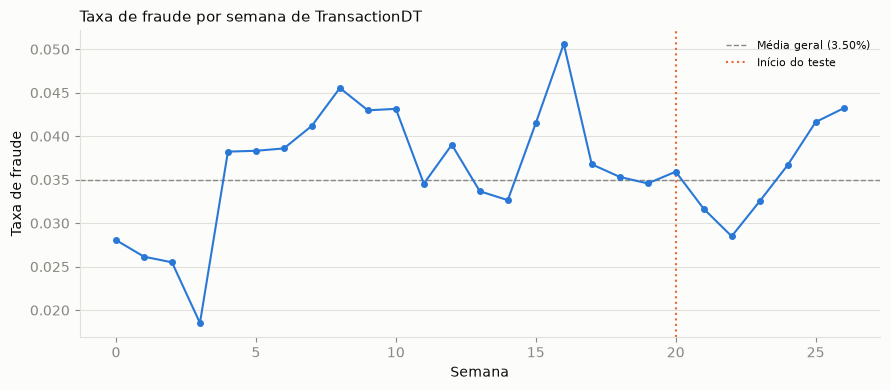

Taxa semanal: mín 1.85% (semana 3), máx 5.06% (semana 16)


In [29]:
week = (df["TransactionDT"] // (7 * 86400)).astype(int)
weekly_rate = df.groupby(week)["isFraud"].agg(["mean", "count"])
weekly_rate.index.name = "semana"

cutoff = df["TransactionDT"].quantile(0.8)
cutoff_week = cutoff // (7 * 86400)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(weekly_rate.index, weekly_rate["mean"], color=COLOR_LEGIT, marker="o", markersize=4, linewidth=1.5, zorder=3)
ax.axhline(df["isFraud"].mean(), color=COLOR_MUTED, linestyle="--", linewidth=1,
           label=f"Média geral ({df['isFraud'].mean():.2%})")
ax.axvline(cutoff_week, color=COLOR_FRAUD, linestyle=":", linewidth=1.5, label="Início do teste")
style_ax(ax, "Taxa de fraude por semana de TransactionDT")
ax.set_xlabel("Semana")
ax.set_ylabel("Taxa de fraude")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fraud_rate_weekly.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Taxa semanal: mín {weekly_rate['mean'].min():.2%} (semana {weekly_rate['mean'].idxmin()}), "
      f"máx {weekly_rate['mean'].max():.2%} (semana {weekly_rate['mean'].idxmax()})")

A taxa de fraude **não é constante**: varia de ~1.9% (semana 3) a ~5.1% (semana 16). As primeiras ~4 semanas formam um regime mais baixo (1.9%–2.8%); a partir da semana 4 a série sobe para um patamar mais alto e ruidoso (~3.3%–5.1%) que persiste até o fim, incluindo o bloco de teste (semanas ~20–26, variando entre 2.85% e 4.32%).

Isso revisa a afirmação da seção 1 do `metodologia.md`: a taxa **agregada** é comparável entre treino (3.51%) e teste (3.44%), mas isso não significa estabilidade **intra-bloco**: o treino em particular mistura dois regimes diferentes. Não invalida o split (o bloco de teste em si não tem a virada abrupta de 5%→2% que seria motivo de alarme), mas justifica monitorar a performance do modelo por semana na validação, não só o agregado.

## Split temporal

In [30]:
train_df, test_df = temporal_train_test_split(df)

print(f"Treino: {len(train_df):,} linhas | fraudes: {train_df['isFraud'].sum():,} | taxa: {train_df['isFraud'].mean():.4%}")
print(f"Teste:  {len(test_df):,} linhas | fraudes: {test_df['isFraud'].sum():,} | taxa: {test_df['isFraud'].mean():.4%}")
print(f"Geral:  {len(df):,} linhas | fraudes: {df['isFraud'].sum():,} | taxa: {df['isFraud'].mean():.4%}")

Treino: 472,432 linhas | fraudes: 16,599 | taxa: 3.5135%
Teste:  118,108 linhas | fraudes: 4,064 | taxa: 3.4409%
Geral:  590,540 linhas | fraudes: 20,663 | taxa: 3.4990%


A taxa de fraude agregada é comparável entre treino (3.51%), teste (3.44%) e geral (3.50%), mas, como visto na seção de estabilidade acima, isso esconde variação real dentro do próprio treino. O split continua sendo a escolha certa (é o único que evita vazamento de futuro), só não deve ser lido como "tudo estável o tempo todo". Decisão e números formalizados em `docs/metodologia.md` (seção 1).